# Notebook 1 SOLUTIONS: Bayesian Optimization on Alanine Dipeptide

Welcome! In this notebook we use **Bayesian Optimization (BO)** to study
the free energy landscape of **alanine dipeptide** — a small molecule that
is a standard benchmark in computational chemistry.

We have two goals:
1. **Learn the force**: use a Gaussian Process to build a surrogate model
   of the mean force f(φ) from sparse observations
2. **Find the free energy minimum**: use BO to efficiently find where
   the force is zero (= minima/maxima of the free energy surface)

---

## Background: alanine dipeptide

Alanine dipeptide (Ace-Ala-Nme) is a small peptide with two backbone
dihedral angles: **φ** (phi) and **ψ** (psi). Despite its simplicity,
it has a rich conformational landscape and is widely used to benchmark
enhanced sampling methods. In this tutorial we focus on φ only, but
the method extends naturally to 2D.

The **free energy surface** (FES) A(φ) tells us how stable each conformation is:
- A **minimum** in A(φ) → stable state (the system spends a lot of time here)
- A **maximum** in A(φ) → unstable state (transition region)

### How do we compute A(φ)?

Computing A(φ) from plain MD is hard — the system rarely visits high-energy
regions. Instead, we use **Umbrella Sampling (US)**: we run many short
simulations, each restrained to a different φ value by a harmonic bias:

$$U_\text{bias}(\phi) = \frac{k}{2}(\phi - \phi_0)^2$$

### From bias to mean force

Because the bias is harmonic, the mean force at φ₀ is easy to measure:

$$f(\phi_0) = \left\langle \frac{\partial U_\text{bias}}{\partial \phi} \right\rangle = k \langle \phi - \phi_0 \rangle$$

We measure the average displacement of φ from φ₀, multiply by k and done.

### From mean force to free energy

Once we have f(φ) = - dA/dφ at enough points, we recover A(φ) by integration:

$$A(\phi) = \int_{\phi_0}^{\phi} - f(\phi') \, d\phi'$$

### The problem and our solution

Each simulation window gives us f(φ) at **one** value of φ. Covering the
full range [-π, π] with many windows is expensive.

**Key insight:** if we can learn f(φ) accurately from just a *few*
well-chosen windows, we save a lot of compute. That is exactly what we
will do using a **Gaussian Process** surrogate and **Bayesian Optimization**.

> **Note:** to keep this tutorial fast, we use data from simulations that
> have already been run. In a real study, each query would launch a new
> umbrella simulation.

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from skopt import Optimizer
from skopt.plots import plot_gaussian_process

## 1. The system: load and visualize

We load a precomputed FES from a metadynamics simulation.
The file has three columns: φ, A(φ), and dA/dφ (the mean force).

In a real study, each point on this curve would require a separate
umbrella simulation.

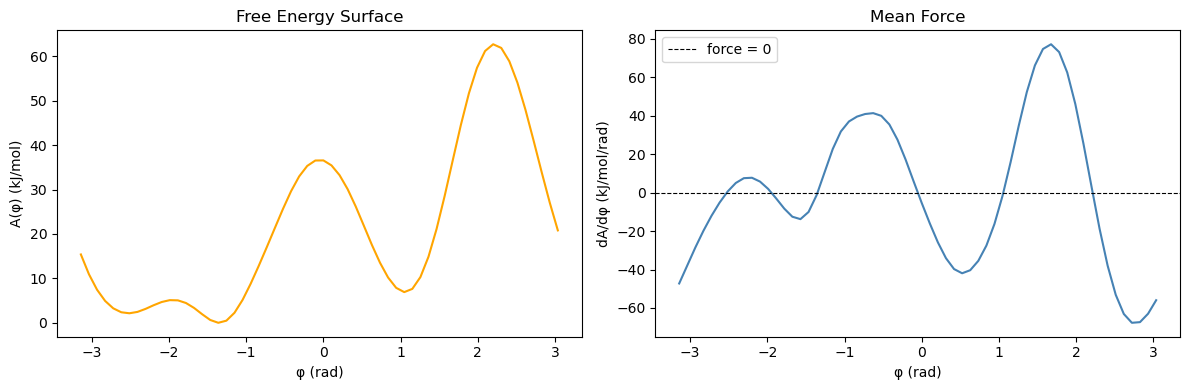

In [ ]:
data = np.loadtxt("fes_adipep_phi.dat", comments="#")

phi           = data[:, 0]   # dihedral angle (rad)
fes           = data[:, 1]   # free energy A(phi) (kJ/mol)
negative_force         = data[:, 2]   # mean force dA/dphi (kJ/mol/rad)

# Shift FES so minimum is at zero
fes -= np.min(fes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(phi, fes, color="orange")
axes[0].set_xlabel("φ (rad)")
axes[0].set_ylabel("A(φ) (kJ/mol)")
axes[0].set_title("Free Energy Surface")

axes[1].plot(phi, negative_force, color="steelblue")
axes[1].axhline(0, color="k", linestyle="--", linewidth=0.8, label="force = 0")
axes[1].set_xlabel("φ (rad)")
axes[1].set_ylabel("dA/dφ (kJ/mol/rad)")
axes[1].set_title("Mean Negative Force")
axes[1].legend()

plt.tight_layout()
plt.show()

**Questions:**
- How many minima does the FES have? Where are they?
  → Three minima: around  φ ≈ -2.5 rad, φ ≈ -1.5 rad and φ ≈ 1.1 rad.
- What is the relationship between the zero crossings of the force
  and the minima/maxima of the FES?
  → Zero crossings of dA/dφ are exactly the extrema of A(φ).
    Negative-to-positive crossings are minima; positive-to-negative are maxima.
- If you could only run 5 simulations, which φ values would you pick?
  → Near the zero crossings and the edges, to capture both shape and extrema.

## 2. Learning the force with a Gaussian Process

A **Gaussian Process (GP)** is a probabilistic model that:
- fits a smooth function through observed data points
- gives a **mean prediction** and an **uncertainty estimate** everywhere

We use `sklearn`'s `GaussianProcessRegressor` directly — this gives us
full control over the kernel and is the right tool for regression
(as opposed to optimization, which is what `skopt` is designed for).

### 2.1 Set up the oracle

In a real study, `f_oracle(phi)` would launch a simulation.
Here it interpolates the precomputed data.

In [52]:
f = interp1d(phi, negative_force, kind="linear", fill_value="extrapolate")

### 2.2 Fit a GP to the force

Complete the function below. It should:
1. Sample `n_points` φ values uniformly across [-π, π]
2. Evaluate the oracle at each point
3. Fit a `GaussianProcessRegressor` with the given kernel
4. Return the fitted GP, the query points, and the observed values

**Hint:** `GaussianProcessRegressor.fit` expects X of shape (n, 1).

In [96]:
def fit_gp(n_points: int, kernel = None) -> tuple:
    """
    Fit a GP to the force using n_points uniformly spaced observations.

    Returns
    -------
    gp : GaussianProcessRegressor
    X_obs : np.ndarray
    y_obs : np.ndarray
    """
    X_obs = np.linspace(np.min(phi), np.max(phi), n_points)
    y_obs = f(X_obs)

    # Simple, robust kernel:
    # - amplitude ~ 50 (roughly the force scale)
    # - lengthscale ~ 1 rad (order of magnitude of structure)
    # - NO WhiteKernel, almost noise-free data

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-6,          # tiny numerical jitter
        normalize_y=True,
        optimizer=None,      # <-- IMPORTANT: or, do the bounds??
    )

    gp.fit(X_obs.reshape(-1, 1), y_obs)
    return gp, X_obs, y_obs

### 2.3 Plot helper

In [97]:
def plot_gp_fit(gp, X_obs, y_obs, title=""):
    """Plot GP mean ± 1σ against the true force."""
    y_pred, sigma = gp.predict(phi.reshape(-1, 1), return_std=True)

    plt.figure(figsize=(9, 4))
    plt.plot(phi, negative_force, label="true force", color="orange", linewidth=2)
    plt.plot(phi, y_pred, label="GP mean", color="steelblue")
    plt.fill_between(phi, y_pred - sigma, y_pred + sigma,
                     alpha=0.3, color="steelblue", label="GP ± 1σ")
    plt.plot(X_obs, y_obs, "k.", markersize=10, label="observations")
    plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
    plt.xlabel("φ (rad)")
    plt.ylabel("dA/dφ (kJ/mol/rad)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 2.4 Experiment with kernels and lengthscales

Try different kernels and lengthscales below and compare the fits.
Use `fit_gp` and `plot_gp_fit` for each combination.

Some kernels to try:
- `RBF(length_scale=0.3)` — short lengthscale: wiggly
- `RBF(length_scale=1.0)` — medium lengthscale
- `RBF(length_scale=3.0)` — long lengthscale: over-smooth
- `Matern(length_scale=1.0, nu=1.5)` — less smooth than RBF
- `Matern(length_scale=1.0, nu=2.5)` — smoother Matérn

Wrap each kernel in `ConstantKernel(50.0) * ... + WhiteKernel(1.0)`
to also fit the amplitude and noise level.

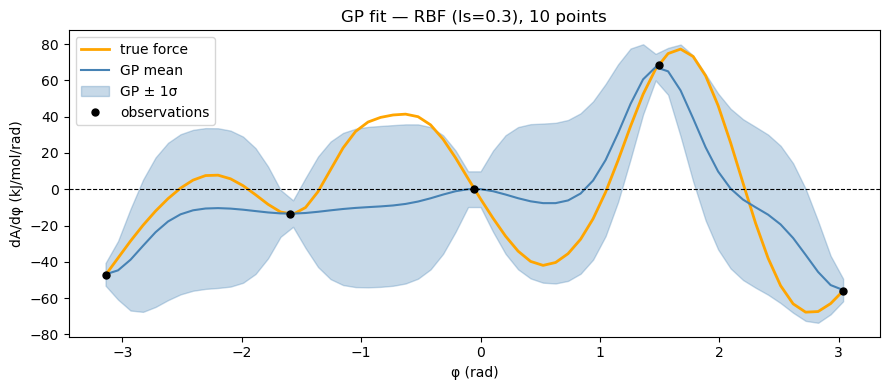

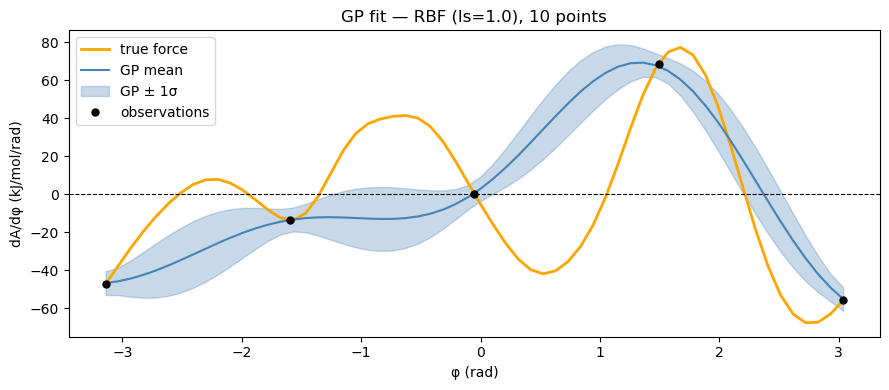

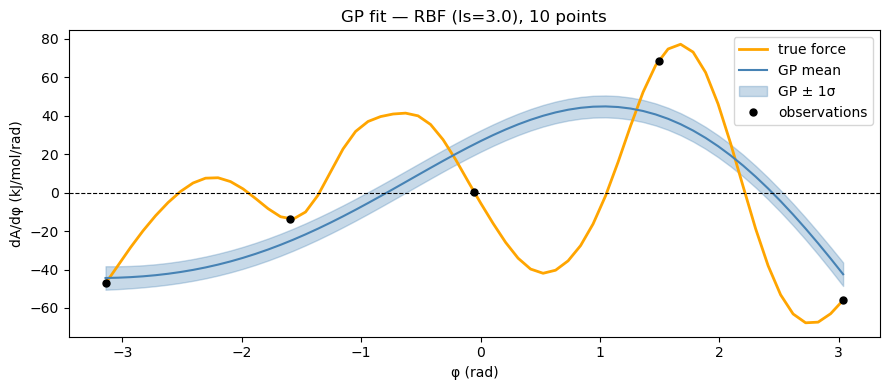

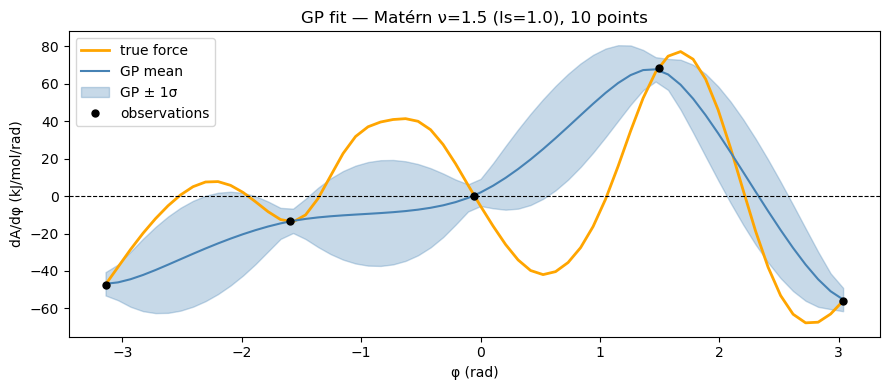

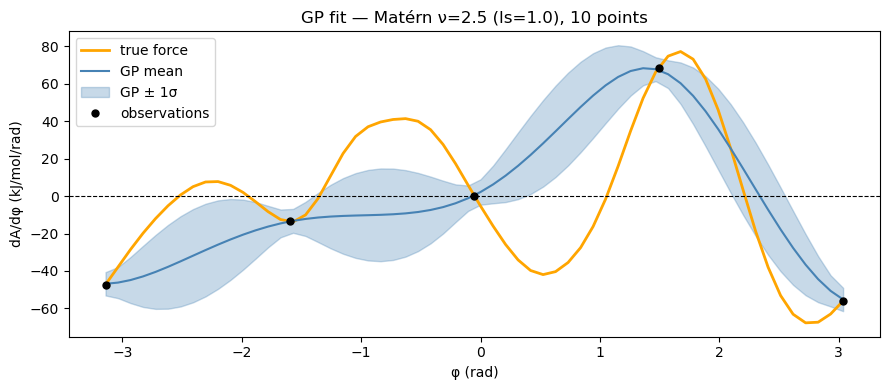

In [101]:
def compare_kernels():
    """Compare GP fits for different kernels and lengthscales."""
    kernels = {
        "RBF (ls=0.3)":      RBF(length_scale=0.3) + WhiteKernel(noise_level=0.01), 
        "RBF (ls=1.0)":         RBF(length_scale=1.0) + WhiteKernel(noise_level=0.01), 
        "RBF (ls=3.0)":          RBF(length_scale=3.0) + WhiteKernel(noise_level=0.01),
        "Matérn ν=1.5 (ls=1.0)": Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=0.01),
        "Matérn ν=2.5 (ls=1.0)":  Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=0.01),
    }

    for name, kernel in kernels.items():
        gp, X_obs, y_obs = fit_gp(n_points=5, kernel=kernel)
        plot_gp_fit(gp, X_obs, y_obs, title=f"GP fit — {name}, 10 points")

compare_kernels()

**Questions:**
- Which kernel fits the force best with 10 points?
- What happens with a very short lengthscale?
- What happens with a very long lengthscale?
- How does the uncertainty band change with lengthscale?

## 3. Finding a minimum: Bayesian Optimization

Now we have a different goal: find a **zero crossing** of the force
as efficiently as possible — i.e. with as few observations as needed.

We minimize **|force(φ)|** with Bayesian Optimization using `skopt`.
The optimizer will:
1. Start with a few random observations
2. Fit a GP to the observations
3. Use an **acquisition function** to pick the next φ to evaluate
4. Repeat

### A note on multiple crossings

The force has **multiple** zero crossings — each corresponds to a
minimum or maximum of A(φ). BO will find *one* of them, depending on
where the random initial points land and how much exploration we allow.
We will see this in action in section 3.3.

### 3.1 Define the objective function

In [102]:
def func(x: list) -> float:
    """
    Objective for BO: returns |force(phi)| at phi = x[0].

    Parameters
    ----------
    x : list
        One-element list [phi_val] as passed by skopt.

    Returns
    -------
    float
        Absolute value of the mean force at phi.
    """
    return float(np.abs(f_oracle(x[0])))


# Sanity check
print(f"|force| at phi=0.0:  {func([0.0]):.4f}")
print(f"|force| at phi=-1.5: {func([-1.5]):.4f}")

|force| at phi=0.0:  5.3371
|force| at phi=-1.5: 11.2643


### 3.2 Run a BO loop

The optimizer setup is provided. Run the loop and observe
which φ values get selected.

> **Try changing:** `acq_func` ("EI", "PI", "LCB"), `n_initial_points`, `n_queries`

In [107]:
acq_func         = "EI"
n_initial_points = 3
n_queries        = 15

opt = Optimizer(
    [(float(np.min(phi)), float(np.max(phi)))],
    base_estimator="GP",
    n_initial_points=n_initial_points,
    acq_func=acq_func,
    acq_optimizer="sampling",
)
opt.space.set_transformer("identity")

for i in range(n_queries):
    next_x = opt.ask()
    f_val  = func(next_x)
    opt.tell(next_x, f_val)
    print(f"Query {i+1:2d}: φ = {next_x[0]:.3f},  |force| = {f_val:.4f}")

print(f"\nBest φ found:          {opt.Xi[np.argmin(opt.yi)][0]:.3f}")
print(f"Minimum |force| found: {np.min(opt.yi):.4f}")

Query  1: φ = -0.585,  |force| = 40.8066
Query  2: φ = -2.876,  |force| = 23.8388
Query  3: φ = -2.934,  |force| = 28.6489
Query  4: φ = -2.687,  |force| = 9.6617
Query  5: φ = -2.452,  |force| = 3.1946
Query  6: φ = 3.036,  |force| = 56.0089
Query  7: φ = -1.895,  |force| = 2.5366
Query  8: φ = 1.135,  |force| = 13.0263
Query  9: φ = -2.119,  |force| = 6.2213
Query 10: φ = -1.578,  |force| = 13.6918
Query 11: φ = 0.530,  |force| = 41.8514
Query 12: φ = 1.665,  |force| = 76.9826
Query 13: φ = -1.816,  |force| = 6.5137
Query 14: φ = -1.168,  |force| = 20.8918
Query 15: φ = -1.959,  |force| = 0.5020

Best φ found:          -1.959
Minimum |force| found: 0.5020


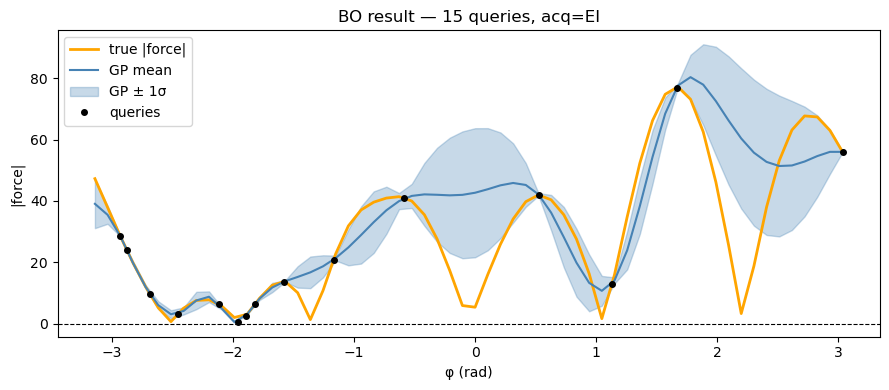

In [108]:
# Visualize: GP on |force| with query locations
gp_bo = opt.models[-1]
y_pred, sigma = gp_bo.predict(phi.reshape(-1, 1), return_std=True)

plt.figure(figsize=(9, 4))
plt.plot(phi, np.abs(negative_force), label="true |force|", color="orange", linewidth=2)
plt.plot(phi, y_pred, label="GP mean", color="steelblue")
plt.fill_between(phi, y_pred - sigma, y_pred + sigma,
                 alpha=0.3, color="steelblue", label="GP ± 1σ")
plt.plot(np.array(opt.Xi).ravel(), opt.yi, "k.", markersize=8, label="queries")
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.xlabel("φ (rad)")
plt.ylabel("|force|")
plt.legend()
plt.title(f"BO result — {n_queries} queries, acq={acq_func}")
plt.tight_layout()
plt.show()

### 3.3 Exploration vs exploitation

Every acquisition function has a parameter controlling the trade-off:
- **Exploitation**: sample where the GP predicts low |force| (near current best)
- **Exploration**: sample where the GP is uncertain (high σ)

| Acquisition | Parameter | Low value → | High value → |
|-------------|-----------|-------------|--------------|
| EI          | `xi`      | exploit     | explore      |
| PI          | `xi`      | exploit     | explore      |
| LCB         | `kappa`   | exploit     | explore      |

Use `run_and_plot` below to compare at least 4 settings and observe:
- which zero crossing gets found
- how many queries are wasted far from any crossing

In [109]:
def run_and_plot(acq_func: str, acq_func_kwargs: dict,
                 n_iter: int = 20, title: str = "") -> Optimizer:
    """
    Run BO with given acquisition settings and plot the result.

    Parameters
    ----------
    acq_func : str
        "EI", "PI", or "LCB".
    acq_func_kwargs : dict
        e.g. {"xi": 0.01} or {"kappa": 2.0}
    n_iter : int
        Total number of evaluations.
    title : str
        Plot title.

    Returns
    -------
    opt : skopt Optimizer
    """
    opt = Optimizer(
        [(float(np.min(phi)), float(np.max(phi)))],
        base_estimator="GP",
        n_initial_points=3,
        acq_func=acq_func,
        acq_optimizer="sampling",
        acq_func_kwargs=acq_func_kwargs,
    )
    opt.space.set_transformer("identity")
    opt.run(func, n_iter=n_iter)

    plot_args = {
        "objective": lambda x: func([x]),
        "show_legend": True,
        "show_title": False,
        "show_next_point": False,
        "show_acq_func": True,
    }
    _ = plot_gaussian_process(opt.get_result(), **plot_args)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    best_phi = opt.Xi[np.argmin(opt.yi)][0]
    print(f"{title}: best φ = {best_phi:.3f}, |force| = {np.min(opt.yi):.4f}")
    return opt

/var/folders/3w/tvg7v4052wzd4djg_0vw2xz40000gn/T/ipykernel_30322/3307763206.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.abs(f_oracle(x[0])))


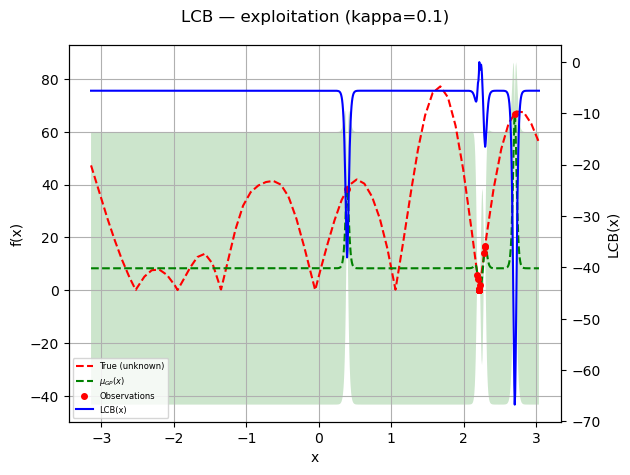

LCB — exploitation (kappa=0.1): best φ = 2.215, |force| = 0.0153


/var/folders/3w/tvg7v4052wzd4djg_0vw2xz40000gn/T/ipykernel_30322/3307763206.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.abs(f_oracle(x[0])))


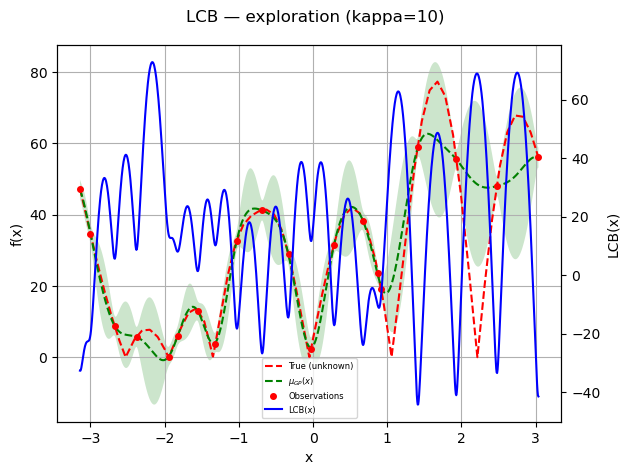

LCB — exploration (kappa=10): best φ = -1.947, |force| = 0.0567


/var/folders/3w/tvg7v4052wzd4djg_0vw2xz40000gn/T/ipykernel_30322/3307763206.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.abs(f_oracle(x[0])))


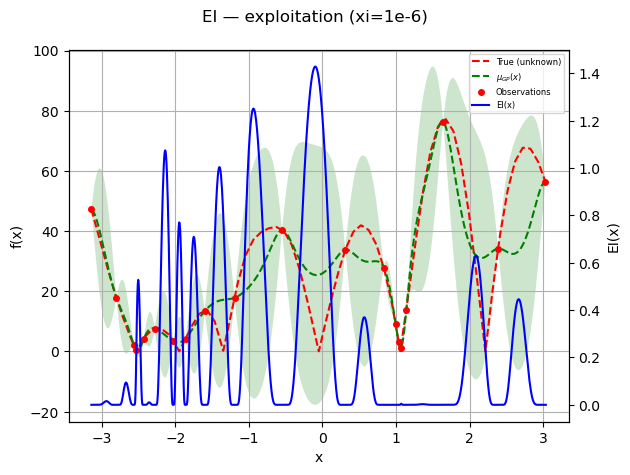

EI — exploitation (xi=1e-6): best φ = -2.535, |force| = 0.5955


/var/folders/3w/tvg7v4052wzd4djg_0vw2xz40000gn/T/ipykernel_30322/3307763206.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.abs(f_oracle(x[0])))


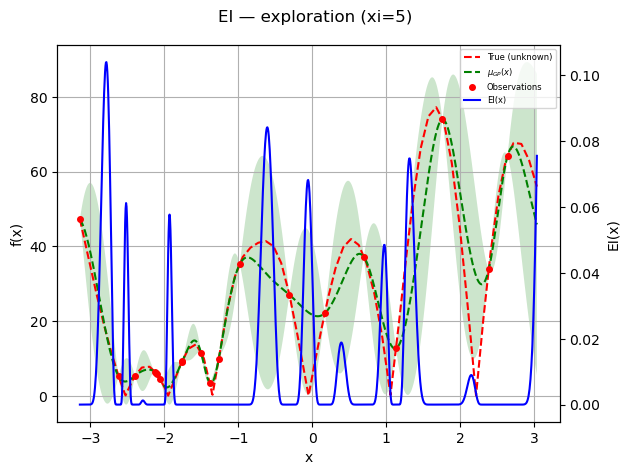

EI — exploration (xi=5): best φ = -1.388, |force| = 3.5147


In [ ]:
# SOLUTION — students fill in the acq_func_kwargs

# LCB — strong exploitation
run_and_plot("LCB", {"kappa": 0.1},  title="LCB — exploitation (kappa=0.1)")

# LCB — strong exploration
run_and_plot("LCB", {"kappa": 10.0}, title="LCB — exploration (kappa=10)")

# EI — strong exploitation
run_and_plot("EI",  {"xi": 1e-6},    title="EI — exploitation (xi=1e-6)")

# EI — strong exploration
run_and_plot("EI",  {"xi": 5.0},     title="EI — exploration (xi=5)")

**Questions:**
- Which setting found a zero crossing most reliably?
  → Moderate settings (EI xi≈0.01, LCB kappa≈1-2) work best.
    Pure exploitation clusters near the first good point found.
    Pure exploration spreads queries but may not converge to any crossing.
- Did different runs find different crossings?
  → Yes — with strong exploitation, the crossing found depends heavily
    on where the 3 random initial points landed.
- How would you find *all* crossings?
  → You would need multiple independent BO runs with different random seeds,
    or a multi-objective / multi-start strategy. With a single run and
    strong exploitation, you will almost always converge to just one.
- Which setting would you choose for real MD simulations?
  → Moderate EI (xi ≈ 0.01–0.1) or LCB (kappa ≈ 1–2): enough exploration
    to avoid getting stuck, enough exploitation to converge efficiently.

## 4. Bonus: from force to free energy

Once we have a GP posterior over the force, we can integrate it to
get a free energy estimate — including **uncertainty bands**.

$$A(\phi) = \int_{\phi_0}^{\phi}-f(\phi') \, d\phi'$$

This is a preview of **Bayesian Quadrature** (notebook 2), where we
will do this properly with a principled acquisition function.

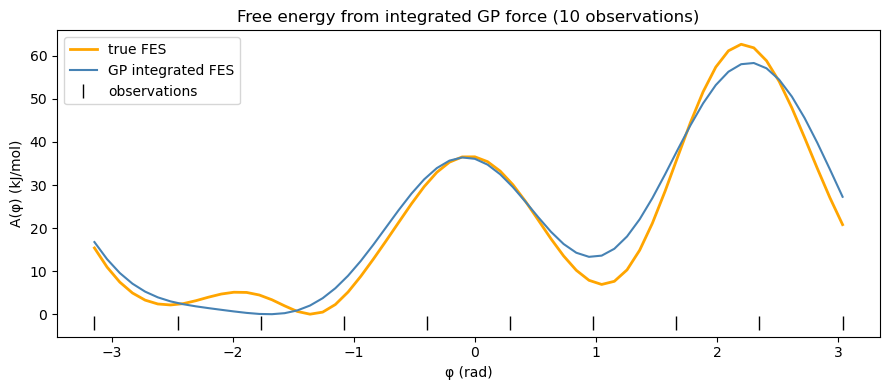

In [ ]:
from scipy.integrate import cumulative_simpson

# Use the GP from section 2 (refit with a good kernel on 10 points)
kernel = ConstantKernel(50.0) * RBF(length_scale=1.0) + WhiteKernel(1.0)
gp_reg, X_obs, y_obs = fit_gp(n_points=10, kernel=kernel)

y_pred, sigma = gp_reg.predict(phi.reshape(-1, 1), return_std=True)

# Cumulative Simpson integration of the mean force
fe_mean = cumulative_simpson(y_pred, x=phi, initial=0.0)

# Shift to zero minimum
fe_mean -= np.min(fe_mean)

plt.figure(figsize=(9, 4))
plt.plot(phi, fes,     color="orange",    linewidth=2, label="true FES")
plt.plot(phi, fe_mean, color="steelblue",             label="GP integrated FES")

plt.plot(
    X_obs,
    f(X_obs) * 0 + np.min(fes) - 2.0,
    "k|",
    markersize=10,
    label="observations",
)
plt.xlabel("φ (rad)")
plt.ylabel("A(φ) (kJ/mol)")
plt.title("Free energy from integrated GP force (10 observations)")
plt.legend()
plt.tight_layout()
plt.show()

**Questions:**
- Where is the integrated FES most accurate? Where does it drift?
  → Accurate near the start of integration; errors accumulate toward
    the right end of the domain (integration error compounds).
- How do the uncertainty bands grow along φ?
  → They widen as φ increases — uncertainty in the force accumulates
    when integrated, so the FES estimate becomes less certain far from φ₀.
- What would happen if you used only 3 observations?
  → The GP fit of the force would be poor, and the integrated FES
    would drift significantly from the true curve.

> **Note:** In **notebook 2** we will use the **IVR acquisition function**,
> which directly minimizes the variance of the integral — giving principled
> uncertainty bands and much better sample efficiency for FES reconstruction.